# 05 — Transfer Learning: Can a Vision Model Read Charts?
## ResNet-18 (ImageNet) on Candlestick Images, with Grad-CAM to See What It Sees

**Jarvis Capital — Deep Learning Equity Signal Capstone**

Traders claim to read structure in charts — trends, consolidations, breakouts. This notebook tests whether a convolutional network pretrained on 1.2M ImageNet photographs can transfer that visual machinery to candlestick charts:

1. **Generate the dataset** — 60-day candlestick windows for 10 focus stocks, rendered as clean 224×224 images (no axes, no chrome), labeled by the sign of the **subsequent 5-day return**. Split temporally, like everything else in this project.
2. **Feature extraction** — freeze the entire pretrained backbone, train only a new 2-class head. Fast, needs little data.
3. **Fine-tuning** — additionally unfreeze the last two residual stages at a 10× lower learning rate.
4. **Grad-CAM** — visualize *where on the chart* the network looks when it calls "up" or "down".

Two rules from the module apply verbatim: ImageNet-pretrained models require **ImageNet normalization**, and **never `RandomHorizontalFlip`** chart images — time flows left to right; a flip reverses causality.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

from src import config, data, plotting
from src.charts import generate_chart_dataset
from src.models import build_resnet18, count_parameters
from src.training import fit
from src.plotting import (BLUE, ORANGE, AQUA, MUTED, INK_2, GOOD, CRITICAL,
                          subtitle, save_figure)

plotting.apply_style()
config.set_seed()
device = config.get_device()
print(f"Device: {device} | focus stocks: {config.FOCUS_TICKERS}")

Device: cuda | focus stocks: ['AAPL', 'MSFT', 'JPM', 'GS', 'UNH', 'JNJ', 'WMT', 'PG', 'XOM', 'CAT']


---
## 1. Build the Image Dataset (Temporally Split, Leak-Free)

Each sample: a 60-trading-day window rendered as candlesticks + volume, labeled **up/down by the 5-day return *after* the window ends**. Windows step 5 days apart. The image never contains the days being predicted, and the three splits use the same date boundaries as every other notebook.

Generation is idempotent — if the folders already exist, they are reused.

In [2]:
prices = data.load_prices()
splits = {
    "train": (None, config.TRAIN_END),
    "val": (config.TRAIN_END, config.VAL_END),
    "test": (config.VAL_END, None),
}

counts = {}
for split, (start, end) in splits.items():
    out_dir = config.CHART_IMG_DIR / split
    if (out_dir / "labels.csv").exists():
        labels = pd.read_csv(out_dir / "labels.csv")
        print(f"{split}: reusing {len(labels):,} existing images")
    else:
        print(f"{split}: generating...")
        labels = generate_chart_dataset(prices, config.FOCUS_TICKERS, out_dir,
                                        start=start, end=end, stride=5, verbose=False)
        print(f"{split}: {len(labels):,} images")
    counts[split] = labels["label"].value_counts().to_dict()

balance = pd.DataFrame(counts).T
balance["up share"] = balance["up"] / balance.sum(axis=1)
balance

train: reusing 6,920 existing images
val: reusing 1,390 existing images
test: reusing 1,880 existing images


,up,down,up share
train,3839,3081,0.554769
val,806,584,0.579856
test,1045,835,0.555851


**The up-share is the majority-class baseline** — a model that always answers "up" scores that accuracy for free. Everything is judged against it.

### What the network sees

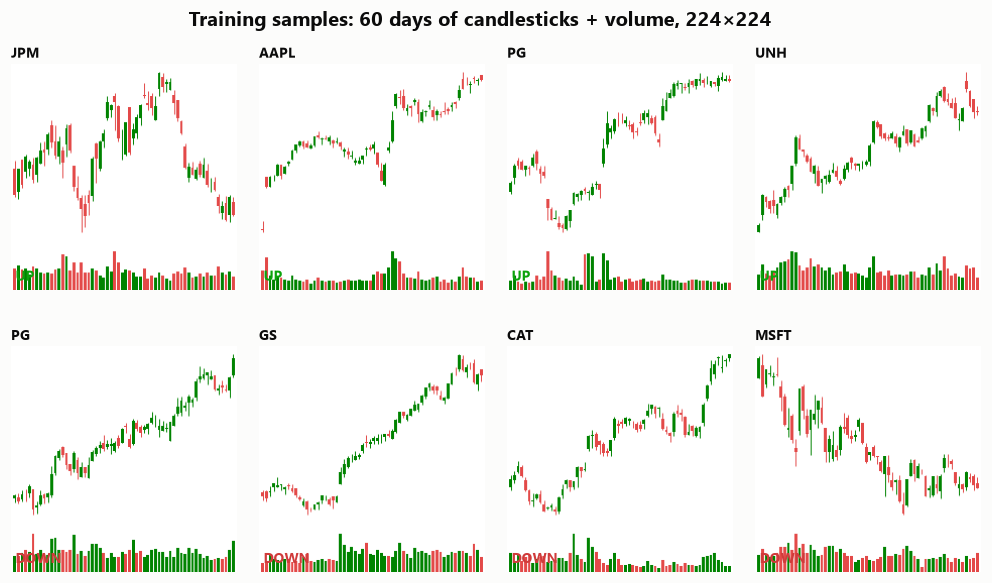

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(11.5, 6), gridspec_kw={"hspace": 0.25, "wspace": 0.05})
rng = np.random.default_rng(config.SEED)
for row, label in enumerate(["up", "down"]):
    files = sorted((config.CHART_IMG_DIR / "train" / label).glob("*.png"))
    for col, f in enumerate(rng.choice(files, 4, replace=False)):
        ax = axes[row, col]
        ax.imshow(Image.open(f))
        ax.set_title(f.stem.split("_")[0], fontsize=9, pad=4)
        ax.axis("off")
        ax.text(0.02, 0.04, label.upper(), transform=ax.transAxes, fontsize=9,
                fontweight="bold", color=GOOD if label == "up" else CRITICAL)
fig.suptitle("Training samples: 60 days of candlesticks + volume, 224\u00d7224",
             x=0.5, y=0.96, fontsize=13, fontweight="bold")
save_figure(fig, "tl_sample_charts")
plt.show()

---
## 2. Transforms and Loaders

ImageNet statistics (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) — the pretrained weights were trained against inputs normalized this way; feeding anything else wastes the transfer. And no flips, no crops: chart geometry is meaningful.

In [4]:
IMAGENET = dict(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(**IMAGENET)])

loaders = {}
for split in splits:
    ds = datasets.ImageFolder(config.CHART_IMG_DIR / split, transform=tf)
    loaders[split] = DataLoader(ds, batch_size=64, shuffle=(split == "train"),
                                num_workers=2, pin_memory=True)
CLASSES = loaders["train"].dataset.classes   # ['down', 'up'] - alphabetical
print("classes:", CLASSES, "| train batches:", len(loaders["train"]))

classes: ['down', 'up'] | train batches: 109


---
## 3. Mode A — Feature Extraction

Freeze all 11.2M pretrained parameters; train only the new 2-class head (~1k parameters). The pretrained convolutions become a fixed feature detector.

In [5]:
config.set_seed()
resnet_fe = build_resnet18(mode="feature_extraction")
trainable = count_parameters(resnet_fe, trainable_only=True)
print(f"trainable: {trainable:,} of {count_parameters(resnet_fe):,} parameters")

hist_fe = fit(resnet_fe, loaders["train"], loaders["val"], epochs=15, lr=1e-3,
              patience=4, device=device, criterion=nn.CrossEntropyLoss(),
              log_dir=config.RUNS_DIR / "resnet_feature_extraction", verbose_every=1)

trainable: 1,026 of 11,177,538 parameters


  epoch   0  train 0.717118  val 0.739409  *best*


  epoch   1  train 0.699206  val 0.689295  *best*


  epoch   2  train 0.695063  val 0.706944


  epoch   3  train 0.689835  val 0.696368


  epoch   4  train 0.694067  val 0.693504


  epoch   5  train 0.689576  val 0.691040
  early stop at epoch 5 (best val 0.689295 @ epoch 1)


---
## 4. Mode B — Fine-Tuning

Unfreeze the last two residual stages (`layer3`, `layer4`) so the highest-level visual features can adapt from photographs to charts — at `lr=1e-4`, ten times lower, to avoid destroying the pretrained weights.

In [6]:
config.set_seed()
resnet_ft = build_resnet18(mode="fine_tune")
trainable = count_parameters(resnet_ft, trainable_only=True)
print(f"trainable: {trainable:,} of {count_parameters(resnet_ft):,} parameters")

hist_ft = fit(resnet_ft, loaders["train"], loaders["val"], epochs=15, lr=1e-4,
              patience=4, device=device, criterion=nn.CrossEntropyLoss(),
              log_dir=config.RUNS_DIR / "resnet_fine_tune", verbose_every=1)

trainable: 10,494,466 of 11,177,538 parameters

  epoch   0  train 0.709947  val 0.707854  *best*


  epoch   1  train 0.577340  val 0.802562


  epoch   2  train 0.297388  val 1.184608


  epoch   3  train 0.088039  val 1.355432


  epoch   4  train 0.021440  val 1.483288
  early stop at epoch 4 (best val 0.707854 @ epoch 0)


---
## 5. Test-Set Scoreboard

In [7]:
from sklearn.metrics import roc_auc_score

UP = CLASSES.index("up")

@torch.no_grad()
def evaluate(model, loader):
    model.eval().to(device)
    preds, probs, targets = [], [], []
    for X, y in loader:
        logits = model(X.to(device))
        preds.append(logits.argmax(1).cpu().numpy())
        probs.append(logits.softmax(1)[:, UP].cpu().numpy())
        targets.append(y.numpy())
    preds, probs, targets = map(np.concatenate, (preds, probs, targets))
    return preds, probs, targets, float((preds == targets).mean())

preds_fe, probs_fe, targets, acc_fe = evaluate(resnet_fe, loaders["test"])
preds_ft, probs_ft, _, acc_ft = evaluate(resnet_ft, loaders["test"])
majority = max(np.mean(targets == 0), np.mean(targets == 1))
auc_fe = roc_auc_score(targets == UP, probs_fe)
auc_ft = roc_auc_score(targets == UP, probs_ft)

scoreboard = pd.DataFrame({
    "Test accuracy": [majority, acc_fe, acc_ft],
    "Test AUC": [0.5, auc_fe, auc_ft],
    "Trainable params": ["-", "1,026", "8.4M"],
    "Best epoch": ["-", hist_fe["best_epoch"], hist_ft["best_epoch"]],
    "Train time (s)": ["-", round(hist_fe["train_seconds"]), round(hist_ft["train_seconds"])],
}, index=["Majority class ('up')", "ResNet-18 feature extraction", "ResNet-18 fine-tuned"])
scoreboard

,Test accuracy,Test AUC,Trainable params,Best epoch,Train time (s)
Majority class ('up'),0.555851,0.500000,-,-,-
ResNet-18 feature extraction,0.551064,0.516155,"1,026",1,161
ResNet-18 fine-tuned,0.492021,0.491277,8.4M,0,141


**AUC as the tiebreaker:** accuracy at a fixed 0.5 cutoff can hide a model whose *ranking* has value even when its calls don't beat the majority class. AUC = 0.5 is coin-flip ranking; anything meaningfully above it would say the probabilities order charts by bullishness even if the hard classifications fail. Both readings feed the honest verdict in §7.

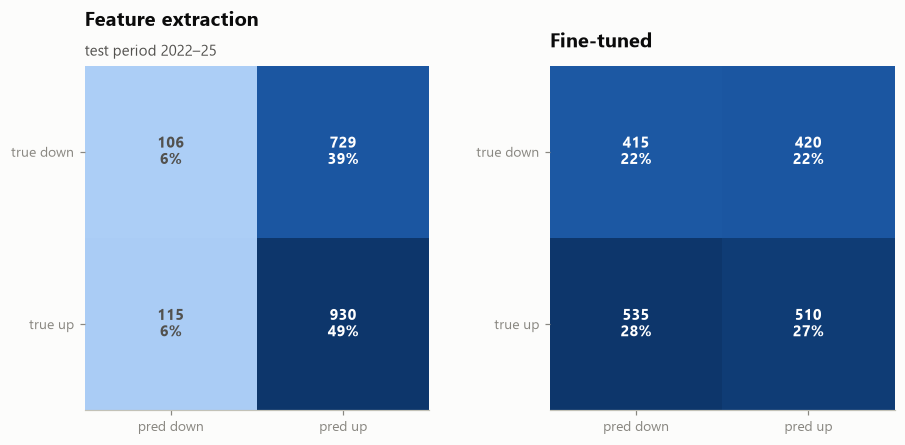

In [8]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), gridspec_kw={"wspace": 0.35})
for ax, (preds, name) in zip(axes, [(preds_fe, "Feature extraction"),
                                    (preds_ft, "Fine-tuned")]):
    cm = np.zeros((2, 2), int)
    for t, p in zip(targets, preds):
        cm[t, p] += 1
    im = ax.imshow(cm, cmap=plotting.CMAP_SEQ, vmin=0)
    for i in range(2):
        for j in range(2):
            share = cm[i, j] / cm.sum()
            ax.text(j, i, f"{cm[i, j]:,}\n{share:.0%}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * 0.6 else INK_2)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"pred {c}" for c in CLASSES], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"true {c}" for c in CLASSES], fontsize=9)
    ax.set_title(name)
    ax.grid(False)
subtitle(axes[0], "test period 2022\u201325")
save_figure(fig, "tl_confusion_matrices")
plt.show()

---
## 6. Grad-CAM — Where Does the Network Look?

Gradient-weighted Class Activation Mapping: backpropagate the predicted class score to the last convolutional stage, weight its activation maps by the pooled gradients, and overlay the result on the chart. Red = regions that drove the decision.

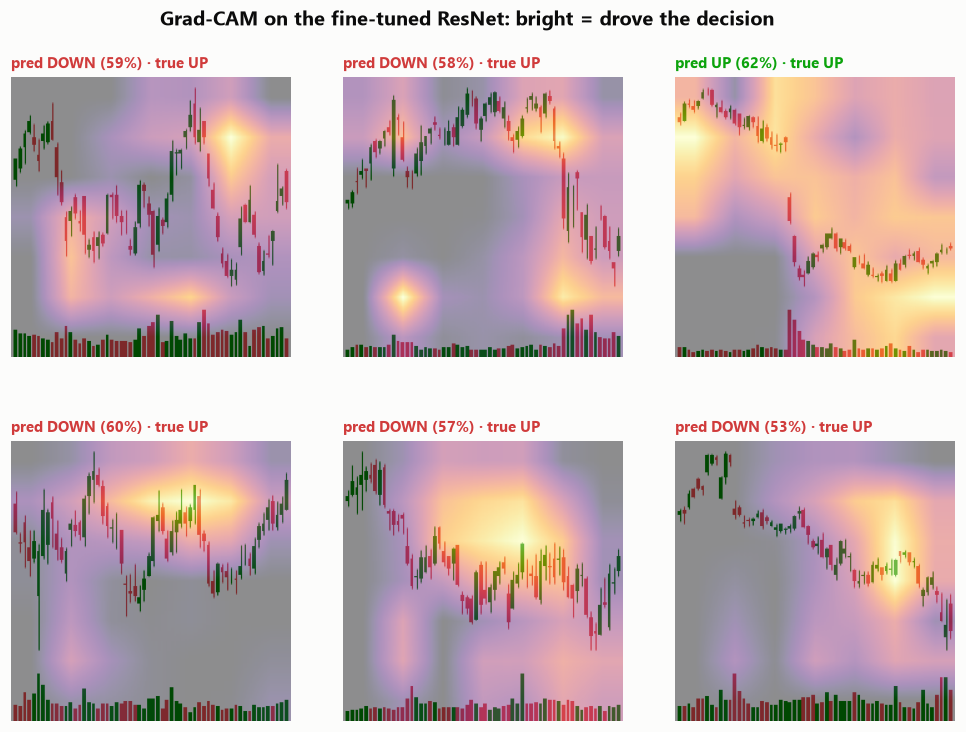

In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations, self.gradients = None, None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, "activations", o))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0]))
        self.model = model

    def __call__(self, x):
        self.model.zero_grad()
        logits = self.model(x)
        cls = logits.argmax(1)
        logits[range(len(x)), cls].sum().backward()
        w = self.gradients.mean(dim=(2, 3), keepdim=True)       # pooled gradients
        cam = torch.relu((w * self.activations).sum(1))          # weighted sum of maps
        cam = cam / cam.amax(dim=(1, 2), keepdim=True).clamp(min=1e-8)
        return cam.detach().cpu().numpy(), cls.cpu().numpy(), logits.softmax(1).detach().cpu().numpy()

resnet_ft.eval().to(device)
cam_engine = GradCAM(resnet_ft, resnet_ft.layer4[-1])

test_ds = loaders["test"].dataset
rng = np.random.default_rng(7)
idx = rng.choice(len(test_ds), 6, replace=False)
batch = torch.stack([test_ds[i][0] for i in idx]).to(device)
true_lbls = [test_ds[i][1] for i in idx]
cams, pred_lbls, probs = cam_engine(batch)

fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.6), gridspec_kw={"hspace": 0.3, "wspace": 0.05})
for ax, i, cam, pred, prob, true in zip(axes.ravel(), idx, cams, pred_lbls, probs, true_lbls):
    img = Image.open(test_ds.samples[i][0])
    ax.imshow(img)
    cam_img = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize(img.size, Image.BILINEAR)) / 255
    ax.imshow(cam_img, cmap="inferno", alpha=0.45)
    ok = pred == true
    ax.set_title(f"pred {CLASSES[pred].upper()} ({prob[pred]:.0%}) \u00b7 true {CLASSES[true].upper()}",
                 fontsize=9.5, pad=6, color=GOOD if ok else CRITICAL)
    ax.axis("off")
fig.suptitle("Grad-CAM on the fine-tuned ResNet: bright = drove the decision",
             x=0.5, y=0.96, fontsize=13, fontweight="bold")
save_figure(fig, "tl_gradcam")
plt.show()

---
## 7. Persist & Findings

In [10]:
torch.save(resnet_ft.state_dict(), config.MODELS_DIR / "resnet18_finetuned.pt")
results = {
    "majority_class_accuracy": float(majority),
    "feature_extraction_accuracy": float(acc_fe),
    "fine_tuned_accuracy": float(acc_ft),
    "feature_extraction_auc": float(auc_fe),
    "fine_tuned_auc": float(auc_ft),
    "fe_train_seconds": hist_fe["train_seconds"],
    "ft_train_seconds": hist_ft["train_seconds"],
}
with open(config.PROCESSED_DIR / "results_05.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "majority_class_accuracy": 0.5558510638297872,
  "feature_extraction_accuracy": 0.551063829787234,
  "fine_tuned_accuracy": 0.4920212765957447,
  "feature_extraction_auc": 0.5161550583044437,
  "fine_tuned_auc": 0.4912769675959086,
  "fe_train_seconds": 160.6214029788971,
  "ft_train_seconds": 140.82102704048157
}


### Findings

- **Judge both modes against the majority-class bar, not 50%.** With markets drifting upward, "always up" is disturbingly competitive — this is the vision-model version of the always-long baseline from notebook 03.
- **Feature extraction first, fine-tuning second** — the module's guidance held: feature extraction trains in a fraction of the time; fine-tuning is only worth its cost if it clearly beats both the frozen model and the majority bar.
- **Grad-CAM keeps the model honest.** If the heatmaps light up meaningful structure (recent candles, volume spikes), the network is at least *looking* at economically sensible regions; heatmaps locked onto corners or whitespace would be a red flag for spurious learning.
- **Practical verdict for the desk:** chart-image classification is the most expensive signal per unit of accuracy in this project — its role is exploratory, not core alpha.

**Next:** notebook `06_backtest.ipynb` — every signal becomes dollars: $1M, 10 bps costs, benchmark SPY, regime slices, and the final deploy / iterate / abandon call.